# Animal Habitat Classification — Model Training

Trains a **MobileNetV3-Small** (via `timm`) on an `ImageFolder`-structured dataset.

The notebook can be tested immediately on **FashionMNIST** (set `USE_FASHION_MNIST = True`)  
and switched to real habitat dataset once it is ready.

Architecture notes
- MobileNetV3-Small: ~2.5 M parameters, fast on GPU does not need a lot
- Dropout is already built into MobileNetV3's classifier head — we expose the rate as `DROPOUT`
- The final linear layer is replaced to match `NUM_CLASSES`
- Hook points for Grad-CAM are preserved (last conv feature map)
- Monte Carlo Dropout is supported at inference time by keeping dropout active (`model.train()` mode trick)

Saved artefacts
- `models/habitat_mobilenetv3_small.pth` — full `state_dict`
- `models/training_history.csv` — per-epoch loss & accuracy


## 0 Setup

In [1]:
import os
import json
from pathlib import Path

import timm
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# config 
# Toggle to True for Fashion_Mnist testing
USE_FASHION_MNIST = False

NUM_CLASSES = 6 # FashionMNIST has 10 classes; our data has 6 classes
EPOCHS = 15
BATCH_SIZE = 32
LR = 1e-4
DROPOUT = 0.2 # Dropout rate in the classifier head
PRETRAINED = True # ImageNet weights; set False to train from scratch
MODEL_NAME = "mobilenetv3_small_100"
SAVE_DIR = Path("models")
DATA_DIR = Path("../data/cut_images/split")  # used when USE_FASHION_MNIST = False

SAVE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"timm : {timm.__version__}")
print(f"torch : {torch.__version__}")

Device : cuda
timm : 1.0.26
torch : 2.11.0+cu126


## 1 · Model Definition

In [2]:
def build_model(num_classes: int, pretrained: bool = PRETRAINED, dropout: float = DROPOUT) -> nn.Module:
    """
    Build a MobileNetV3-Small via timm.

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    pretrained : bool
        Load ImageNet weights when True.
    dropout : float
        Dropout rate applied inside the classifier head.
        Keeping this > 0 lets you do MC-Dropout at inference time later.

    Returns
    -------
    nn.Module
        Model on CPU (caller is responsible for .to(device)).
    """
    model = timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=dropout, # timm exposes dropout via drop_rate
    )
    return model


# Quick summary
_m = build_model(NUM_CLASSES)
total_params = sum(p.numel() for p in _m.parameters())
train_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Model : {MODEL_NAME}")
print(f"Total params : {total_params:,}")
print(f"Trainable params : {train_params:,}")
del _m

Model : mobilenetv3_small_100
Total params : 1,524,006
Trainable params : 1,524,006


## 2 · Data Loading

Two modes:
- **FashionMNIST** — auto-downloaded, 3-channel, resized to 224 × 224 so it runs through the same pipeline (therefore it also takes quite a long while to load)
- **PrepData** — expects `PrepData/Training`, `PrepData/Validation`, `PrepData/Test` in `ImageFolder` format

In [ ]:
def get_timm_transforms(model: nn.Module):
    config = timm.data.resolve_model_data_config(model)
    train_tf = timm.data.create_transform(**config, is_training=True)
    val_tf = timm.data.create_transform(**config, is_training=False)
    
    train_tf.transforms.insert(0, transforms.RandomRotation(10))
    
    return train_tf, val_tf


def load_fashion_mnist(model: nn.Module, batch_size: int = BATCH_SIZE):
    """
    FashionMNIST in 3-channel 224x224 mode.
    Splits the 60 k training set 80/20 into train/val.
    """
    config = timm.data.resolve_model_data_config(model)
    mean, std = config["mean"], config["std"]
    img_size = config["input_size"][1]  # usually 224

    shared_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.Grayscale(num_output_channels=3),  # FashionMNIST is greyscale
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    train_aug = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    full_train = datasets.FashionMNIST("data", train=True,  download=True, transform=train_aug)
    test_ds = datasets.FashionMNIST("data", train=False, download=True, transform=shared_tf)

    n_val = int(0.2 * len(full_train))
    n_train = len(full_train) - n_val
    train_ds, val_ds = random_split(full_train, [n_train, n_val],
                                    generator=torch.Generator().manual_seed(42))
    # val set should use non-augmented transforms
    val_ds.dataset = datasets.FashionMNIST("data", train=True, download=False, transform=shared_tf)

    kw = dict(batch_size=batch_size, pin_memory=True)
    return (
        DataLoader(train_ds, shuffle=True, **kw),
        DataLoader(val_ds, shuffle=False, **kw),
        DataLoader(test_ds, shuffle=False, **kw),
        train_ds, val_ds, test_ds,
    )


# def load_prepdata(model: nn.Module, batch_size: int = BATCH_SIZE):
#     """Load from PrepData/Training, PrepData/Validation, PrepData/Test."""
#     train_tf, val_tf = get_timm_transforms(model)
#     train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_tf, allow_empty=True)
#     val_ds   = datasets.ImageFolder(DATA_DIR / "val", transform=val_tf, allow_empty=True)
#     test_ds  = datasets.ImageFolder(DATA_DIR / "test", transform=val_tf, allow_empty=True)

#     kw = dict(batch_size=batch_size, pin_memory=True)
#     return (
#         DataLoader(train_ds, shuffle=True, **kw),
#         DataLoader(val_ds, shuffle=False, **kw),
#         DataLoader(test_ds, shuffle=False, **kw),
#         train_ds, val_ds, test_ds,
#     )

def load_prepdata(model: nn.Module, batch_size: int = BATCH_SIZE):
    train_aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2),
        transforms.ToTensor()
    ])
    val_test_aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_aug)
    val_ds = datasets.ImageFolder(DATA_DIR / "val", transform=val_test_aug)
    test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=val_test_aug)

    kw = dict(batch_size=batch_size, num_workers=0, pin_memory=True)
    return (
        DataLoader(train_ds, shuffle=True, **kw),
        DataLoader(val_ds, shuffle=False, **kw),
        DataLoader(test_ds, shuffle=False,  **kw),
        train_ds, val_ds, test_ds,
    )



# Build model first (transforms depend on it)
model = build_model(NUM_CLASSES, pretrained=PRETRAINED).to(device)

if USE_FASHION_MNIST:
    print("Using FashionMNIST (sanity-check mode)")
    train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = load_fashion_mnist(model)
else:
    print("Using PrepData (real dataset mode)")
    train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = load_prepdata(model)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
print(test_ds.class_to_idx)

Using PrepData (real dataset mode)
Train: 194 | Val: 63 | Test: 69
{'dense': 0, 'dense_snow': 1, 'open': 2, 'open_snow': 3, 'sparse': 4, 'sparse_snow': 5}


## 3 · Training Helpers

In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        n += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate on a dataloader. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        n += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def test_model(model, loader):
    """Run on test set. Returns (accuracy, balanced_accuracy, preds, labels)."""
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        logits = model(images.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return acc, bal_acc, all_preds, all_labels


def plot_curves(history: dict, title: str = "Training Curves"):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, history["train_loss"], label="Train", marker="o", ms=3)
    ax1.plot(ep, history["val_loss"], label="Val", marker="o", ms=3)
    ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, [a * 100 for a in history["train_acc"]], label="Train", marker="o", ms=3)
    ax2.plot(ep, [a * 100 for a in history["val_acc"]], label="Val", marker="o", ms=3)
    ax2.set(xlabel="Epoch", ylabel="Accuracy (%)", title="Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## 4 · Training Loop

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in tqdm(range(EPOCHS), desc="Epochs"):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(
        f"Epoch {epoch+1:>2}/{EPOCHS}  "
        f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
        f"val_loss={va_loss:.4f}  val_acc={va_acc:.3f}"
    )

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  1/15  train_loss=2.8900  train_acc=0.448  val_loss=2.5526  val_acc=0.381
Epoch  2/15  train_loss=0.8315  train_acc=0.789  val_loss=1.9558  val_acc=0.381
Epoch  3/15  train_loss=0.5833  train_acc=0.866  val_loss=0.7160  val_acc=0.778
Epoch  4/15  train_loss=0.3989  train_acc=0.876  val_loss=0.9451  val_acc=0.762
Epoch  5/15  train_loss=0.4052  train_acc=0.887  val_loss=0.6904  val_acc=0.794
Epoch  6/15  train_loss=0.2623  train_acc=0.912  val_loss=1.1551  val_acc=0.730
Epoch  7/15  train_loss=0.1810  train_acc=0.959  val_loss=1.6830  val_acc=0.667
Epoch  8/15  train_loss=0.3387  train_acc=0.907  val_loss=1.5122  val_acc=0.730
Epoch  9/15  train_loss=0.1455  train_acc=0.948  val_loss=0.7290  val_acc=0.794
Epoch 10/15  train_loss=0.2058  train_acc=0.948  val_loss=0.2514  val_acc=0.905
Epoch 11/15  train_loss=0.3894  train_acc=0.876  val_loss=0.4472  val_acc=0.857
Epoch 12/15  train_loss=0.5148  train_acc=0.876  val_loss=0.1975  val_acc=0.889
Epoch 13/15  train_loss=0.3058  train_ac

## 5 · Results

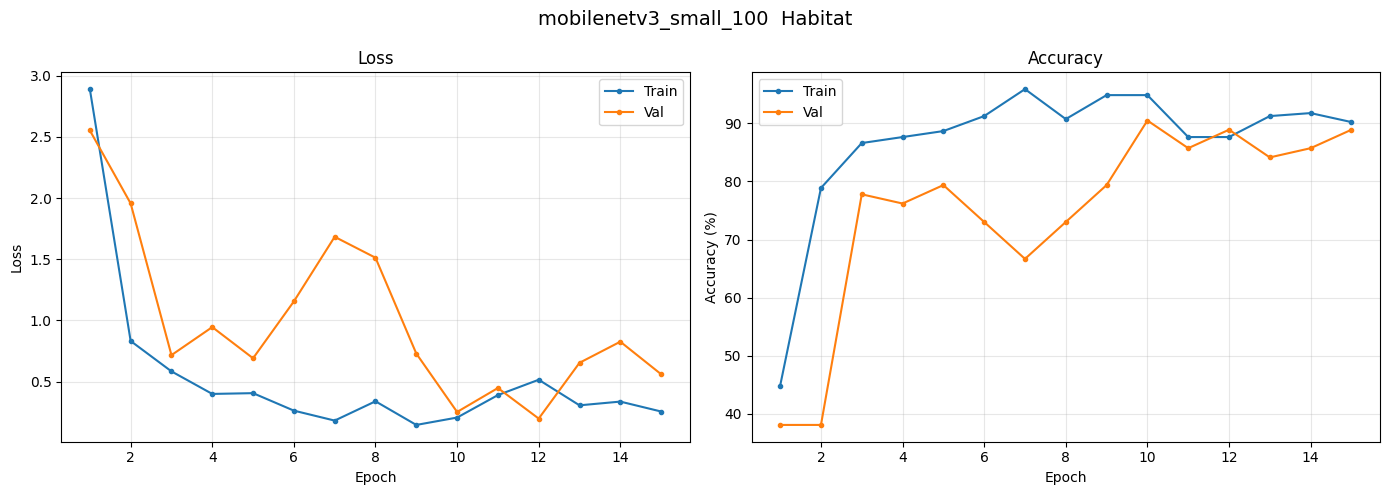

In [10]:
plot_curves(history, title=f"{MODEL_NAME}  {'FashionMNIST' if USE_FASHION_MNIST else 'Habitat'}")

In [11]:
acc, bal_acc, preds, labels = test_model(model, test_loader)
print(f"Test Accuracy : {acc:.2%}")
print(f"Test Balanced Accuracy : {bal_acc:.2%}")

Test Accuracy : 91.30%
Test Balanced Accuracy : 76.66%


## 6 · Save Model & History

The `.pth` file contains only the `state_dict` — portable and Git LFS-friendly.  
A small metadata JSON is saved alongside so you always know how the checkpoint was produced.

In [12]:
tag = "fashionmnist" if USE_FASHION_MNIST else "habitat"
ckpt_path = SAVE_DIR / f"habitat_mobilenetv3_small_{tag}.pth"
history_csv = SAVE_DIR / f"training_history_{tag}.csv"
meta_path = SAVE_DIR / f"meta_{tag}.json"

# State dict only — load with: model = build_model(N); model.load_state_dict(torch.load(path))
torch.save(model.state_dict(), ckpt_path)
print(f"Checkpoint saved : {ckpt_path}")

# Training history
pd.DataFrame(history).to_csv(history_csv, index=False)
print(f"History saved : {history_csv}")

# Metadata for reproducibility
meta = {
    "model_name" : MODEL_NAME,
    "num_classes" : NUM_CLASSES,
    "pretrained" : PRETRAINED,
    "dropout" : DROPOUT,
    "epochs" : EPOCHS,
    "batch_size" : BATCH_SIZE,
    "lr" : LR,
    "test_acc" : round(acc, 4),
    "test_bal_acc": round(bal_acc, 4),
    "dataset" : tag,
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Metadata saved : {meta_path}")
print(json.dumps(meta, indent=2))

Checkpoint saved : models\habitat_mobilenetv3_small_habitat.pth
History saved : models\training_history_habitat.csv
Metadata saved : models\meta_habitat.json
{
  "model_name": "mobilenetv3_small_100",
  "num_classes": 6,
  "pretrained": true,
  "dropout": 0.2,
  "epochs": 15,
  "batch_size": 32,
  "lr": 0.0001,
  "test_acc": 0.913,
  "test_bal_acc": 0.7666,
  "dataset": "habitat"
}


## 7 · How to Load the Checkpoint in Other Notebooks

```python
import timm, torch

NUM_CLASSES = 6  # match what you trained with
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "mobilenetv3_small_100",
    pretrained=False,
    num_classes=NUM_CLASSES,
    drop_rate=0.2,
)
model.load_state_dict(torch.load("models/habitat_mobilenetv3_small_fashionmnist.pth", map_location=device))
model = model.to(device)
model.eval()
```

### Grad-CAM target layer
```python
# The last depthwise conv block before the global pool
target_layer = [model.blocks[-1]]   # works with pytorch-grad-cam
```

### Monte Carlo Dropout at inference
```python
def mc_dropout_predict(model, image_tensor, n_samples=30):
    model.train()  # keeps dropout active
    with torch.no_grad():
        logits = torch.stack([model(image_tensor) for _ in range(n_samples)])
    probs = logits.softmax(-1)
    return probs.mean(0), probs.std(0)  # mean prediction, epistemic uncertainty
```
